In [1]:
import csv
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/nue_properties.csv")

In [3]:
from scipy.stats import norm
from scipy import stats

# Example: column named 'values'
start_dir_x = df['start_dir_x']
start_dir_y = df['start_dir_y']
start_dir_z = df['start_dir_z']
ke = df['ke']

# Fit a normal distribution
mu_x, sigma_x = norm.fit(start_dir_x)
mu_y, sigma_y = norm.fit(start_dir_y)
mu_z, sigma_z = norm.fit(start_dir_z)

print(f"Mean (μ) X: {mu_x}")
print(f"Standard deviation (σ) X: {sigma_x}")

print(f"Mean (μ) y: {mu_y}")
print(f"Standard deviation (σ) y: {sigma_y}")

print(f"Mean (μ) z: {mu_z}")
print(f"Standard deviation (σ) z: {sigma_z}")

Mean (μ) X: -0.0008531345831568165
Standard deviation (σ) X: 0.28406547002277405
Mean (μ) y: -0.09901535089548963
Standard deviation (σ) y: 0.2790018194801542
Mean (μ) z: 0.8741286785051804
Standard deviation (σ) z: 0.259921295832552


Sample from fitted Pareto distribution: [-0.9861351]


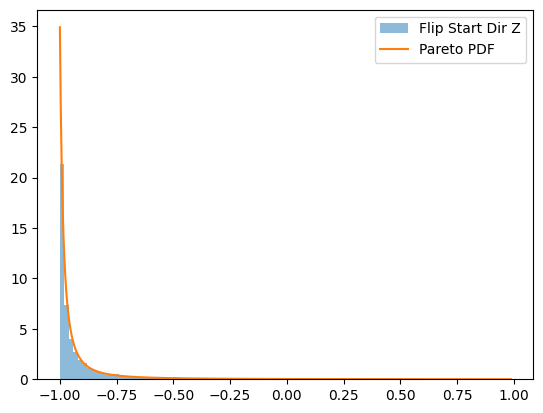

In [4]:
flip_start_dir_z = -start_dir_z
#beta_params = stats.beta.fit(start_dir_z)
pareto_params = stats.pareto.fit(flip_start_dir_z)

# Create x values
x = np.linspace(flip_start_dir_z.min(), flip_start_dir_z.max(), 1000)

# Evaluate PDF
pdf = stats.pareto.pdf(x, *pareto_params)

samples = stats.pareto.rvs(*pareto_params, size=1)
print(f"Sample from fitted Pareto distribution: {samples}")


import matplotlib.pyplot as plt

plt.hist(flip_start_dir_z, bins=100, density=True, alpha=0.5, label='Flip Start Dir Z')
plt.plot(x, pdf, label='Pareto PDF')
#plt.ylim(0, 100)
plt.legend()
plt.show()

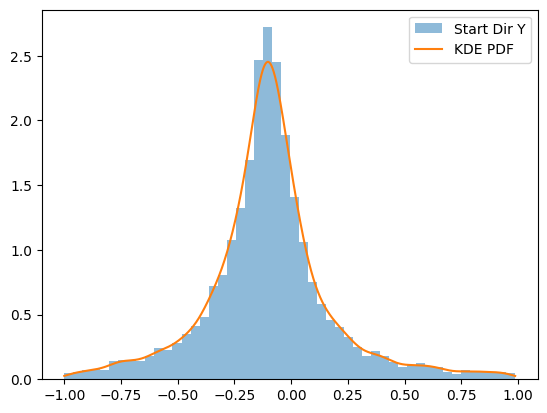

In [5]:
kde = stats.gaussian_kde(start_dir_y)

# Create x values
x = np.linspace(start_dir_y.min(), start_dir_y.max(), 1000)

# Evaluate PDF
pdf = kde(x)

import matplotlib.pyplot as plt

plt.hist(start_dir_y, bins=50, density=True, alpha=0.5, label='Start Dir Y')
plt.plot(x, pdf, label='KDE PDF')
plt.legend()
plt.show()

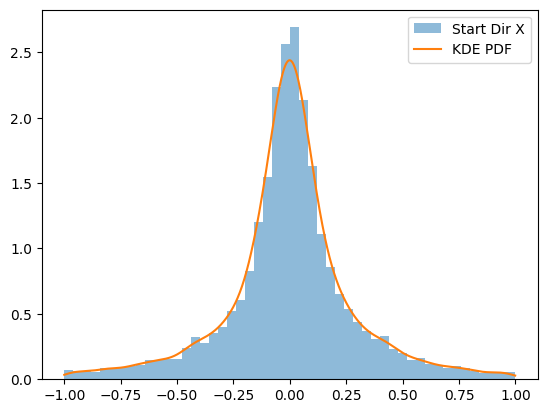

In [6]:
kde = stats.gaussian_kde(start_dir_x)
# Create x values
x = np.linspace(start_dir_x.min(), start_dir_x.max(), 1000)

# Evaluate PDF
pdf = kde(x)

import matplotlib.pyplot as plt

plt.hist(start_dir_x, bins=50, density=True, alpha=0.5, label='Start Dir X')
plt.plot(x, pdf, label='KDE PDF')
plt.legend()
plt.show()

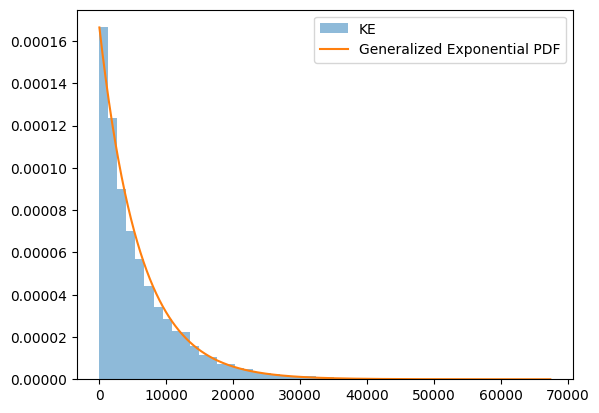

In [7]:

genexpon_params = stats.genexpon.fit(ke)

# Create x values
x = np.linspace(ke.min(), ke.max(), 1000)

# Evaluate PDF
pdf = stats.genexpon.pdf(x, *genexpon_params)

import matplotlib.pyplot as plt

plt.hist(ke, bins=50, density=True, alpha=0.5, label='KE')
plt.plot(x, pdf, label='Generalized Exponential PDF')
plt.legend()
plt.show()

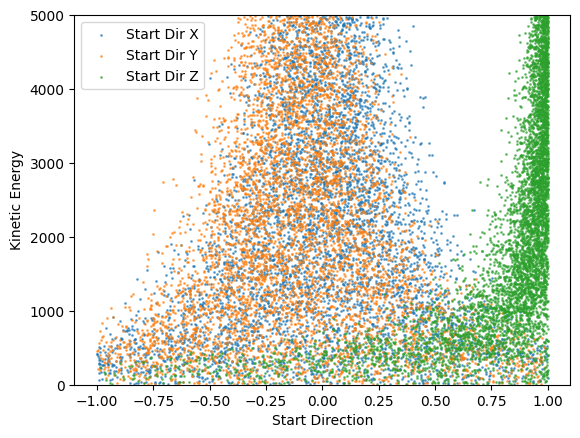

In [9]:
plt.scatter(start_dir_x, ke, label="Start Dir X", marker='o', s=1, alpha=0.6)
plt.scatter(start_dir_y, ke, label="Start Dir Y", marker='o', s=1, alpha=0.6)
plt.scatter(start_dir_z, ke, label="Start Dir Z", marker='o', s=1, alpha=0.6)
plt.ylabel("Kinetic Energy")
plt.xlabel("Start Direction")
plt.ylim(0, 5000)
plt.legend()
plt.show()